In [ ]:
#Dataset link: https://www.kaggle.com/datasets/puneet6060/intel-image-classification

In [ ]:
!pip install -q kaggle

In [ ]:
!mkdir ~/.kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/kaggle.json

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 99% 344M/346M [00:00<00:00, 368MB/s]
100% 346M/346M [00:00<00:00, 466MB/s]


In [ ]:
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
for dirpath, dirname, filenames in os.walk("/content/seg_train"):
  print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'.")

There are 1 directories and 0 images in '/content/seg_train'.
There are 6 directories and 0 images in '/content/seg_train/seg_train'.
There are 0 directories and 2382 images in '/content/seg_train/seg_train/street'.
There are 0 directories and 2274 images in '/content/seg_train/seg_train/sea'.
There are 0 directories and 2404 images in '/content/seg_train/seg_train/glacier'.
There are 0 directories and 2512 images in '/content/seg_train/seg_train/mountain'.
There are 0 directories and 2271 images in '/content/seg_train/seg_train/forest'.
There are 0 directories and 2191 images in '/content/seg_train/seg_train/buildings'.


In [ ]:
for dirpath, dirname, filenames in os.walk("/content/seg_test"):
  print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'.")

There are 1 directories and 0 images in '/content/seg_test'.
There are 6 directories and 0 images in '/content/seg_test/seg_test'.
There are 0 directories and 501 images in '/content/seg_test/seg_test/street'.
There are 0 directories and 510 images in '/content/seg_test/seg_test/sea'.
There are 0 directories and 553 images in '/content/seg_test/seg_test/glacier'.
There are 0 directories and 525 images in '/content/seg_test/seg_test/mountain'.
There are 0 directories and 474 images in '/content/seg_test/seg_test/forest'.
There are 0 directories and 437 images in '/content/seg_test/seg_test/buildings'.


In [ ]:
for dirpath, dirname, filenames in os.walk("/content/seg_pred"):
  print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'.")

There are 1 directories and 0 images in '/content/seg_pred'.
There are 0 directories and 7301 images in '/content/seg_pred/seg_pred'.


In [ ]:
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  target_folder = target_dir + target_class

  random_image = random.sample(os.listdir(target_folder),1)

  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"image shape: {img.shape}")

  return img

image shape: (150, 150, 3)


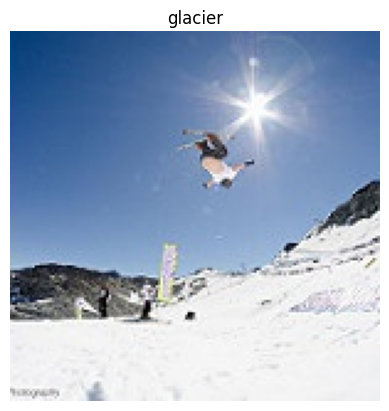

In [ ]:
img = view_random_image(target_dir="/content/seg_train/seg_train/",
                        target_class="glacier")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#set the seed
tf.random.set_seed(42)

#preprocess the data(Scaling)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

#setting up the train and test directories
train_dir = "/content/seg_train/seg_train/"
test_dir = "/content/seg_test/seg_test/"

#Importing the data from directories and turning them to batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(150,150),
                                               class_mode="categorical",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(150,150),
                                               class_mode="categorical",
                                               seed=42)



Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout,GlobalAveragePooling2D, Activation
from tensorflow.keras.optimizers import Adam

model_custom_CNN = Sequential([
    Conv2D(filters=10,
           kernel_size=3,
           strides=1,
           activation='relu',
           input_shape=(150,150,3)),
    MaxPool2D(pool_size=2),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(6,activation='softmax')
])

model_custom_CNN.compile(loss='categorical_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

model_custom_CNN.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2890)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        17,346 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,446 (75.96 KB)

 Trainable params: 19,446 (75.96 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
intial_epochs=5

history_1 = model_custom_CNN.fit(train_data,
                        epochs=intial_epochs,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data)
                        )

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.4994 - loss: 1.2284 - val_accuracy: 0.7310 - val_loss: 0.7734
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.7245 - loss: 0.7452 - val_accuracy: 0.7610 - val_loss: 0.6747
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.7666 - loss: 0.6519 - val_accuracy: 0.7600 - val_loss: 0.6678
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.7845 - loss: 0.6041 - val_accuracy: 0.7180 - val_loss: 0.7477
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.7979 - loss: 0.5600 - val_accuracy: 0.7917 - val_loss: 0.6099


In [ ]:
def plot_loss_curve(history):

  train_loss = history.history['loss']
  val_loss = history.history['val_loss']

  train_acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']

  epochs = range(len(train_loss))

  plt.plot(epochs,train_loss,label='train_loss')
  plt.plot(epochs,val_loss,label='val_loss')
  plt.title('loss')
  plt.xlabel('epochs')
  plt.legend()

  plt.figure()
  plt.plot(epochs,train_acc,label='train_acc')
  plt.plot(epochs,val_acc,label='val_acc')
  plt.title('accuracy')
  plt.xlabel('epochs')
  plt.legend();


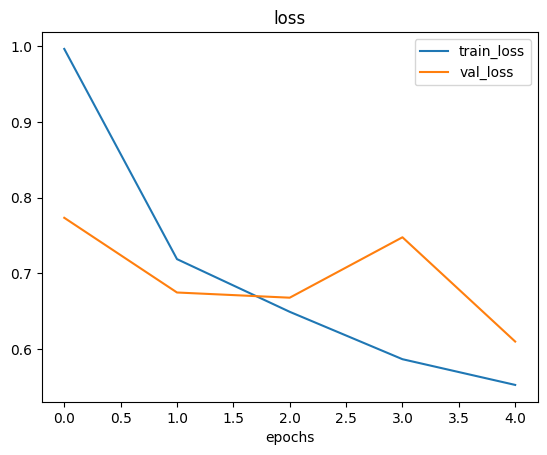

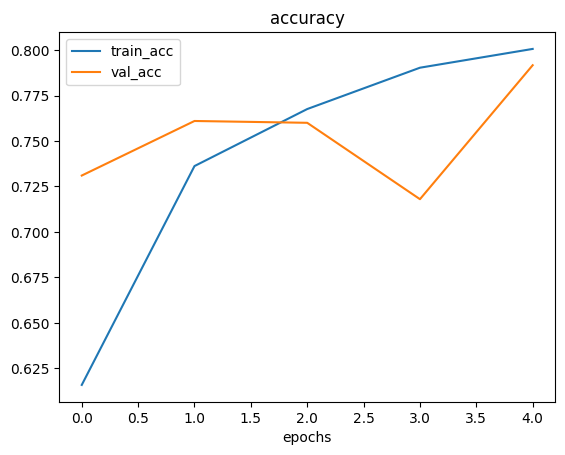

In [ ]:
plot_loss_curve(history_1)

In [ ]:
#save the model_1
model_custom_CNN.save("/content/drive/MyDrive/models/intel-image-custom_CNN.h5")

In [ ]:
from tensorflow.keras.models import load_model
model_1_loaded = load_model("/content/drive/MyDrive/models/intel-image-custom_CNN.h5")

In [ ]:
model_1_loaded.evaluate(valid_data)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7845 - loss: 0.6105


[0.6098546981811523, 0.7916666865348816]

In [ ]:
#Data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255,
                                             rotation_range=20,
                                             zoom_range=0.2,
                                             shear_range=0.2,
                                             width_shift_range=0.2,
                                             height_shift_range=0.2,
                                             horizontal_flip=True)

train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   batch_size=32,
                                                                   target_size=(224,224),
                                                                   class_mode='categorical',
                                                                   seed=42)
valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="categorical",
                                               seed=42)


Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
#Create tensorboard callbacks
import datetime
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"saving Tensorboard log files to: {log_dir}")
  return tensorboard_callback

SAVE_DIR = "/content/drive/MyDrive/models/model_logs"

In [ ]:
from tensorflow.keras import layers

#creating base model
input_shape = (224,224,3)
base_model = tf.keras.applications.VGG16(include_top=False)
base_model.trainable = False

#creating Functional model
inputs = layers.Input(shape=input_shape, name='input_layer')
x=base_model(inputs, training=False)
x=layers.GlobalAveragePooling2D(name="poolinglayer")(x)
x=layers.Dense(256)(x)
x=layers.Dense(6)(x)
outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)
model_VGG = tf.keras.Model(inputs, outputs)

#compiling the model
model_VGG.compile(loss="categorical_crossentropy",
                           optimizer=tf.keras.optimizers.Adam(),
                           metrics=["accuracy"])

model_VGG.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ poolinglayer                    │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint_cb = ModelCheckpoint(
    filepath="/content/drive/MyDrive/models/intel-image-model_VGG.h5",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    save_weights_only=False
)

intial_epochs = 5
history_VGG = model_VGG.fit(train_data_augmented,
                            epochs=intial_epochs,
                            steps_per_epoch=len(train_data_augmented),
                            validation_data=valid_data,
                            validation_steps=len(valid_data),
                            callbacks=[create_tensorboard_callback(SAVE_DIR,
                                                                   "VGG16"),
                                       checkpoint_cb])

saving Tensorboard log files to: /content/drive/MyDrive/models/model_logs/VGG16/20250902-090151


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.6603 - loss: 0.9027

439/439 ━━━━━━━━━━━━━━━━━━━━ 238s 504ms/step - accuracy: 0.6605 - loss: 0.9021 - val_accuracy: 0.8323 - val_loss: 0.4755
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8176 - loss: 0.4902

439/439 ━━━━━━━━━━━━━━━━━━━━ 228s 460ms/step - accuracy: 0.8176 - loss: 0.4902 - val_accuracy: 0.8607 - val_loss: 0.3979
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 266s 470ms/step - accuracy: 0.8277 - loss: 0.4575 - val_accuracy: 0.8540 - val_loss: 0.3967
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 257s 458ms/step - accuracy: 0.8297 - loss: 0.4446 - val_accuracy: 0.8507 - val_loss: 0.4069
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8373 - loss: 0.4363

439/439 ━━━━━━━━━━━━━━━━━━━━ 206s 470ms/step - accuracy: 0.8374 - loss: 0.4362 - val_accuracy: 0.8623 - val_loss: 0.3855


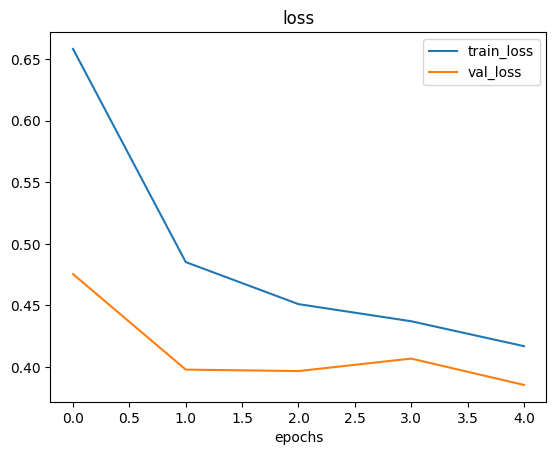

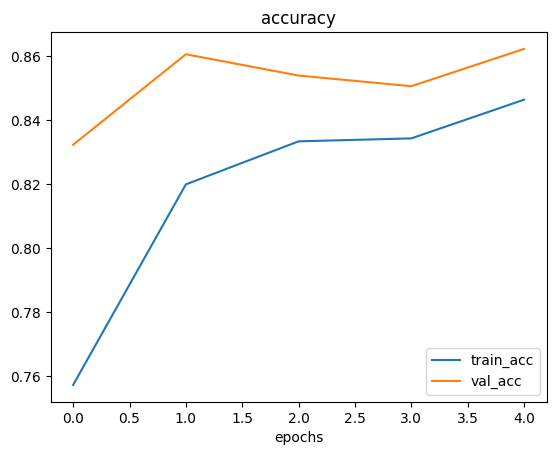

In [ ]:
plot_loss_curve(history_VGG)

In [ ]:
from tensorflow.keras.models import load_model
model_VGG_loaded = load_model("/content/drive/MyDrive/models/intel-image-model_VGG.h5")

In [ ]:
model_VGG_loaded.evaluate(valid_data)

94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.8572 - loss: 0.3990


[0.3854673206806183, 0.862333357334137]

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-10]:
  layer.trainable = False

model_VGG.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(1e-4),
                metrics=["accuracy"])

In [ ]:
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_1 False
1 block1_conv1 False
2 block1_conv2 False
3 block1_pool False
4 block2_conv1 False
5 block2_conv2 False
6 block2_pool False
7 block3_conv1 False
8 block3_conv2 False
9 block3_conv3 True
10 block3_pool True
11 block4_conv1 True
12 block4_conv2 True
13 block4_conv3 True
14 block4_pool True
15 block5_conv1 True
16 block5_conv2 True
17 block5_conv3 True
18 block5_pool True


In [ ]:
checkpoint_cb = ModelCheckpoint(
    filepath="/content/drive/MyDrive/models/intel-image-model_VGG_finetune.h5",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    save_weights_only=False
)

finetune_epochs = 5
history_VGG_finetune = model_VGG.fit(train_data_augmented,
                                     epochs=finetune_epochs,
                                     steps_per_epoch=len(train_data_augmented),
                                     validation_data=valid_data,
                                     validation_steps=len(valid_data),
                                     callbacks=[create_tensorboard_callback(SAVE_DIR,
                                                                            "VGG_finetune"),
                                               checkpoint_cb])


saving Tensorboard log files to: /content/drive/MyDrive/models/model_logs/VGG_finetune/20250902-093227
Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.7604 - loss: 0.6471

439/439 ━━━━━━━━━━━━━━━━━━━━ 235s 535ms/step - accuracy: 0.7606 - loss: 0.6467 - val_accuracy: 0.8203 - val_loss: 0.5747
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.8761 - loss: 0.3554

439/439 ━━━━━━━━━━━━━━━━━━━━ 250s 508ms/step - accuracy: 0.8761 - loss: 0.3553 - val_accuracy: 0.8993 - val_loss: 0.2680
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 260s 503ms/step - accuracy: 0.8965 - loss: 0.2963 - val_accuracy: 0.8993 - val_loss: 0.2917
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 262s 503ms/step - accuracy: 0.9062 - loss: 0.2602 - val_accuracy: 0.8810 - val_loss: 0.3560
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 221s 503ms/step - accuracy: 0.9133 - loss: 0.2411 - val_accuracy: 0.8877 - val_loss: 0.3741


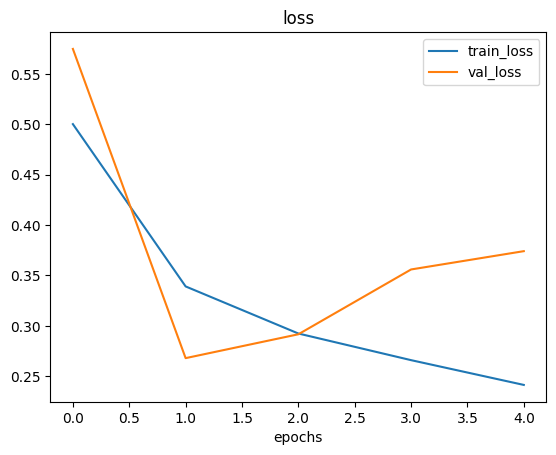

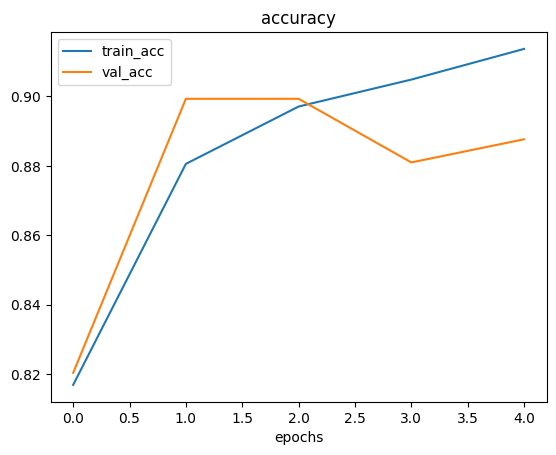

In [ ]:
plot_loss_curve(history_VGG_finetune)

In [ ]:
model_VGG_finetune_loaded = load_model("/content/drive/MyDrive/models/intel-image-model_VGG_finetune.h5")
model_VGG_finetune_loaded.evaluate(valid_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 309ms/step - accuracy: 0.9034 - loss: 0.2571


[0.2680318355560303, 0.8993333578109741]

In [ ]:
valid_data = valid_datagen.flow_from_directory(
    test_dir,
    batch_size=32,
    target_size=(150,150),
    class_mode="categorical",
    shuffle=False,
    seed=42
)

Found 3000 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 160ms/step


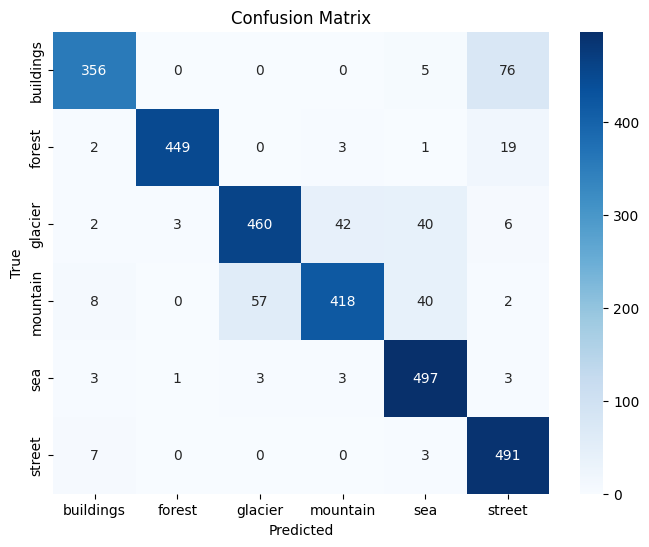

Classification Report:

              precision    recall  f1-score   support

   buildings       0.94      0.81      0.87       437
      forest       0.99      0.95      0.97       474
     glacier       0.88      0.83      0.86       553
    mountain       0.90      0.80      0.84       525
         sea       0.85      0.97      0.91       510
      street       0.82      0.98      0.89       501

    accuracy                           0.89      3000
   macro avg       0.90      0.89      0.89      3000
weighted avg       0.90      0.89      0.89      3000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model_VGG.predict(valid_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = valid_data.classes
class_labels = list(valid_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step


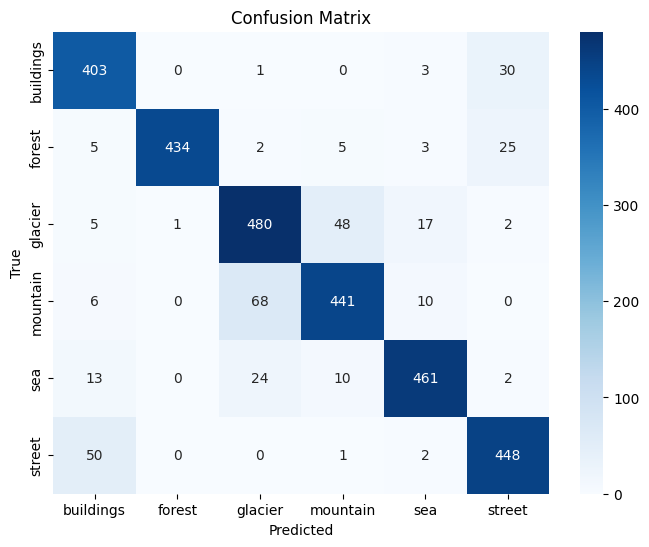

Classification Report:

              precision    recall  f1-score   support

   buildings       0.84      0.92      0.88       437
      forest       1.00      0.92      0.95       474
     glacier       0.83      0.87      0.85       553
    mountain       0.87      0.84      0.86       525
         sea       0.93      0.90      0.92       510
      street       0.88      0.89      0.89       501

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model_VGG_finetune_loaded.predict(valid_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = valid_data.classes
class_labels = list(valid_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))